# TCS-Net Optimized — Fair Comparison Run

**Model:** TCS-Net (Temporal-Cross-Spectrogram Network)

**Purpose:** Produce per-fold OOF predictions in the shared fair-comparison format so this
model can be compared head-to-head with VIPEEGNet and EfficientNetB0.

**Fairness alignment with the other two models:**
- 5-fold GroupKFold on `patient_id` — loaded from `patient_folds.csv` (identical patients per
  fold as VIPEEGNet and EfficientNetB0).
- Same deduplication as VIPEEGNet: `drop_duplicates(['eeg_id'] + vote columns)`.
- HQ evaluation subset: segments with `votes >= 10` (VIPEEGNet protocol).
- Sample weighting: `votes/20` during training (VIPEEGNet protocol).

**Native TCS-Net recipe preserved:**
- 200 Hz EEG
- 16-channel bipolar montage + channel swap (VIPEEGNet convention).
- Dual 8-channel spectrogram (4 Kaggle + 4 EEG-derived, Deotte's exact librosa params).
- EEG temporal encoder: SumToOne stem + 3 ResNet1D blocks + 2-layer transformer with RoPE.
- VIPEEGNet-style EEG-to-image branch (supplementary; compact 4-conv CNN).
- Spectrogram encoder: EfficientNetV2-S, 8-channel adapted stem.
- Cross-Modal Token Attention (CMTA) + Frequency Band Gate.
- 3-stage training: 15 ep warmup (all data) + 12 ep fine-tune (HQ) + 6 ep polish (HQ).
- Per-fold temperature scaling at inference.



## 1. Environment — install PyTorch on the TF template


In [1]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124 -q

In [2]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124 -q
!pip install timm librosa -q

import torch
print(f'PyTorch {torch.__version__} | CUDA: {torch.cuda.is_available()} | '
      f'GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None"}')

PyTorch 2.6.0+cu124 | CUDA: True | GPU: NVIDIA GeForce RTX 4090


In [3]:
import os, gc, copy, math, time, warnings, random, json
from pathlib import Path
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.signal import butter, filtfilt
from sklearn.metrics import roc_auc_score, confusion_matrix
import librosa

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler
import timm

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
SEED   = 2024
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
print(f'Device: {DEVICE} | Seed: {SEED}')

Device: cuda | Seed: 2024


In [4]:
# ---------- paths ----------
DATA_DIR   = '/workspace/hms-data'
EEG_DIR    = f'{DATA_DIR}/train_eegs'
SPEC_DIR   = f'{DATA_DIR}/train_spectrograms'

FAIR_DIR   = '/workspace/fair_comparison'
OUT_DIR    = f'{FAIR_DIR}/tcsnet'
WEIGHTS    = f'{OUT_DIR}/weights'
CACHE_DIR  = '/workspace/tcsnet_cache'   # shared with previous TCS-Net runs

for d in [OUT_DIR, WEIGHTS, CACHE_DIR]:
    Path(d).mkdir(parents=True, exist_ok=True)

# ---------- hyperparameters (Optimized TCS-Net — fair-comparison variant) ----------
N_FOLDS    = 5
BATCH_SIZE = 16          # RTX 4090 24GB with mixed precision
E1, E2, E3 = 15, 12, 6   # 3-stage training

SR       = 200           # keep 200 Hz (improvement #1 from TCS-Net Fair)
EEG_LEN  = 10_000        # 50 s × 200 Hz
N_CH     = 16

LABEL_COLS  = ['seizure_vote','lpd_vote','gpd_vote','lrda_vote','grda_vote','other_vote']
CLASS_NAMES = ['Seizure','LPD','GPD','LRDA','GRDA','Other']

# Bipolar montage (18 ch, middle two dropped later — VIPEEGNet convention)
BRAIN_18 = [
    'Fp1-F7','F7-T3','T3-T5','T5-O1',
    'Fp1-F3','F3-C3','C3-P3','P3-O1',
    'Fz-Cz','Cz-Pz',
    'Fp2-F4','F4-C4','C4-P4','P4-O2',
    'Fp2-F8','F8-T4','T4-T6','T6-O2',
]
FLIP_PAIRS = [(0,4),(1,5),(2,6),(3,7),(8,12),(9,13),(10,14),(11,15)]

# Path sanity
assert os.path.isfile(f'{DATA_DIR}/train.csv')
assert os.path.isdir(EEG_DIR) and os.path.isdir(SPEC_DIR)
assert os.path.isfile(f'{FAIR_DIR}/patient_folds.csv'), \
    'Run 00_generate_fair_splits.ipynb first.'

print(f'Config: {N_FOLDS} folds | BS={BATCH_SIZE} | stages={E1}+{E2}+{E3} | EEG@{SR}Hz')
print(f'OUT_DIR   = {OUT_DIR}')
print(f'CACHE_DIR = {CACHE_DIR}')

Config: 5 folds | BS=16 | stages=15+12+6 | EEG@200Hz
OUT_DIR   = /workspace/fair_comparison/tcsnet
CACHE_DIR = /workspace/tcsnet_cache


## 2. Data — VIPEEGNet-style dedup + shared patient folds


In [5]:
df_full = pd.read_csv(f'{DATA_DIR}/train.csv')
print(f'Full manifest: {len(df_full):,} segments')

# VIPEEGNet's dedup: one row per (eeg_id + vote pattern)
train = df_full.drop_duplicates(
    ['eeg_id'] + LABEL_COLS
).reset_index(drop=True)
print(f'Deduplicated: {len(train):,} rows')

# Preserve raw votes for weighting and HQ filter
TARGETS_RAW = [c + '_raw' for c in LABEL_COLS]
train[TARGETS_RAW] = train[LABEL_COLS].values

# Normalize votes -> probability distribution
y = train[LABEL_COLS].values.astype(np.float32)
y = y / y.sum(axis=1, keepdims=True)
train[LABEL_COLS] = y

train['total_votes_raw'] = train[TARGETS_RAW].sum(axis=1)

# Merge the shared patient -> fold mapping
pf = pd.read_csv(f'{FAIR_DIR}/patient_folds.csv')
train = train.merge(pf, on='patient_id', how='left')
assert train['fold'].notna().all(), 'some rows have no fold — patient_folds.csv is incomplete'
train['fold'] = train['fold'].astype(int)

print(f'\n{"Fold":>4} | {"Segments":>9} | {"HQ (v>=10)":>10} | {"patients":>8}')
print('-' * 45)
for k in range(N_FOLDS):
    fd = train[train.fold == k]
    hq = fd[fd.total_votes_raw >= 10]
    print(f'{k:>4} | {len(fd):>9,} | {len(hq):>10,} | {fd["patient_id"].nunique():>8,}')

Full manifest: 106,800 segments
Deduplicated: 20,183 rows

Fold |  Segments | HQ (v>=10) | patients
---------------------------------------------
   0 |     4,421 |      1,341 |      390
   1 |     3,863 |      1,378 |      390
   2 |     4,360 |      1,251 |      390
   3 |     3,837 |      1,242 |      390
   4 |     3,702 |      1,138 |      390


## 3. EEG and dual-spectrogram preprocessing + cache


In [6]:
# Butterworth filter — VIPEEGNet params (order 3, 0.5-45 Hz)
b_filt, a_filt = butter(3, np.float32([0.5, 45]) * 2 / SR, 'bandpass')

def preprocess_eeg_recording(eeg_id):
    '''Load full recording, 18-ch bipolar, clip -> filter. Returns (18, T) float32.'''
    raw = pd.read_parquet(f'{EEG_DIR}/{eeg_id}.parquet')
    chs = []
    for ch in BRAIN_18:
        c1, c2 = ch.split('-')
        if c1 in raw.columns and c2 in raw.columns:
            d = raw[c1].values - raw[c2].values
        else:
            d = np.zeros(len(raw))
        d[np.isnan(d)] = 0
        chs.append(d.reshape(1, -1))
    eeg = np.concatenate(chs, axis=0)
    eeg = np.clip(eeg, -1024, 1024)
    eeg = filtfilt(b_filt, a_filt, eeg, axis=1)
    return eeg.astype(np.float32)

def eeg_to_spec_4ch(raw_parquet_path, offset=0):
    '''EEG-derived 4-channel mel spectrogram (Deotte's librosa params).'''
    raw = pd.read_parquet(raw_parquet_path)
    s, e = int(offset * SR), int(offset * SR) + EEG_LEN
    if e > len(raw):
        e = len(raw); s = max(0, e - EEG_LEN)
    raw = raw.iloc[s:e]
    bipolar_pairs = [
        [('Fp1','F7'),('F7','T3'),('T3','T5'),('T5','O1')],   # LL
        [('Fp2','F8'),('F8','T4'),('T4','T6'),('T6','O2')],   # RL
        [('Fp1','F3'),('F3','C3'),('C3','P3'),('P3','O1')],   # LP
        [('Fp2','F4'),('F4','C4'),('C4','P4'),('P4','O2')],   # RP
    ]
    specs = []
    for chain in bipolar_pairs:
        sigs = []
        for c1, c2 in chain:
            if c1 in raw.columns and c2 in raw.columns:
                sigs.append(raw[c1].values - raw[c2].values)
            else:
                sigs.append(np.zeros(len(raw)))
        avg = np.nanmean(sigs, axis=0).astype(np.float32)
        avg = np.where(np.isfinite(avg), avg, 0.0)
        S = librosa.feature.melspectrogram(
            y=avg, sr=SR, n_fft=1024, hop_length=128, n_mels=128,
            fmin=0, fmax=20, power=2.0, window='hann', center=True)
        S = 10.0 * np.log10(S + 1e-6)
        S = np.clip(S, -60, 60)
        S = (S + 60) / 120
        from PIL import Image
        if S.shape != (128, 256):
            S = np.array(Image.fromarray((S * 255).astype(np.uint8)).resize((256, 128), 1)) / 255
        specs.append(S.astype(np.float32))
    return np.stack(specs)

def parse_kaggle_spec(spec_path, offset=0):
    '''Parse Kaggle spectrogram parquet -> 4ch (128x256).'''
    from PIL import Image
    df = pd.read_parquet(spec_path)
    ctr = min(int(offset * 2) + 600, len(df))
    s, e = max(0, ctr - 600), min(len(df), ctr + 600)
    df = df.iloc[s:e]
    specs = []
    for chain in ['LL','RL','LP','RP']:
        cols = sorted(
            [c for c in df.columns if c.startswith(chain + '_') and c != 'time'],
            key=lambda x: float(x.split('_', 1)[1]),
        )
        S = np.zeros((100, 300), dtype=np.float32)
        if cols and len(df) > 0:
            try:
                r = df[cols].values.T.astype(np.float32)
                r = np.where(np.isfinite(r), r, 0)
                r = np.log1p(np.clip(r, 0, None))
                mn, mx = r.min(), r.max()
                S = (r - mn) / (mx - mn + 1e-8) if mx > mn else np.zeros_like(r)
            except Exception:
                pass
        img = Image.fromarray((S * 255).astype(np.uint8)).resize((256, 128), 1)
        specs.append(np.array(img).astype(np.float32) / 255)
    return np.stack(specs)

print('Preprocessing functions defined.')

Preprocessing functions defined.


In [7]:
from tqdm.auto import tqdm

# Cache 18-channel EEG recordings at 200 Hz
ids = train['eeg_id'].unique()
cached = sum(1 for e in ids if os.path.exists(f'{CACHE_DIR}/{e}_eeg.npy'))
print(f'EEG recordings: {len(ids):,} | cached: {cached:,}')

if cached < len(ids):
    print('Caching EEG recordings (~20 min)...')
    for eid in tqdm(ids, desc='EEG'):
        p = f'{CACHE_DIR}/{eid}_eeg.npy'
        if not os.path.exists(p):
            np.save(p, preprocess_eeg_recording(eid))

# Cache dual 8-channel spectrograms (per (eeg_id, spectrogram_id) pair)
cached_s = sum(
    1 for _, r in train.iterrows()
    if os.path.exists(f'{CACHE_DIR}/{r.eeg_id}_{r.get("spectrogram_id", r.eeg_id)}_spec8.npy')
)
print(f'Spectrograms: {len(train):,} | cached: {cached_s:,}')

if cached_s < len(train):
    print('Caching spectrograms (~40 min)...')
    for _, r in tqdm(train.iterrows(), total=len(train), desc='Spec'):
        eid  = r['eeg_id']
        sid  = r.get('spectrogram_id', eid)
        off  = r.get('eeg_label_offset_seconds', 0)
        soff = r.get('spectrogram_label_offset_seconds', 0)
        sp   = f'{CACHE_DIR}/{eid}_{sid}_spec8.npy'
        if os.path.exists(sp):
            continue
        eeg_spec = eeg_to_spec_4ch(f'{EEG_DIR}/{eid}.parquet', off)
        kg_path  = f'{SPEC_DIR}/{sid}.parquet'
        kg = parse_kaggle_spec(kg_path, soff) if os.path.exists(kg_path) \
             else np.zeros((4, 128, 256), dtype=np.float32)
        np.save(sp, np.concatenate([kg, eeg_spec], axis=0).astype(np.float32))

# Load EEGs into memory for fast random access during training
print('Loading EEGs into memory...')
eegs = {eid: np.load(f'{CACHE_DIR}/{eid}_eeg.npy') for eid in tqdm(ids, desc='Loading')}
print(f'Loaded {len(eegs)} recordings.')

EEG recordings: 17,089 | cached: 17,089
Spectrograms: 20,183 | cached: 20,183
Loading EEGs into memory...


Loading:   0%|          | 0/17089 [00:00<?, ?it/s]

Loaded 17089 recordings.


## 4. Augmentations + Dataset


In [8]:
def aug_brain_flip(eeg, spec):
    eeg2 = eeg.copy()
    for i, j in FLIP_PAIRS:
        eeg2[i], eeg2[j] = eeg[j].copy(), eeg[i].copy()
    spec2 = spec.copy()
    spec2[0], spec2[1] = spec[1].copy(), spec[0].copy()
    spec2[2], spec2[3] = spec[3].copy(), spec[2].copy()
    spec2[4], spec2[5] = spec[5].copy(), spec[4].copy()
    spec2[6], spec2[7] = spec[7].copy(), spec[6].copy()
    return eeg2, spec2

def aug_time_reverse(eeg, spec):
    return eeg[:, ::-1].copy(), spec[:, :, ::-1].copy()

def aug_channel_dropout(eeg, max_drop=4):
    eeg = eeg.copy()
    n = random.randint(1, max_drop)
    for _ in range(n):
        ch = random.randint(0, eeg.shape[0]-1)
        eeg[ch] = 0
    return eeg

# FIX 2: random temporal shift (±1s @ 50Hz = ±50 samples; at 200Hz = ±200 samples)
# At 200Hz keep 1s = 200 samples of shift capacity
SHIFT_MAX = 200

In [9]:
class TCSDataset(Dataset):
    def __init__(self, df, mode='train', hq_only=False):
        self.mode = mode
        self.is_train = (mode == 'train')
        if hq_only:
            df = df[df.total_votes_raw >= 10].reset_index(drop=True)
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        eid = row['eeg_id']
        sid = row.get('spectrogram_id', eid)

        # Segment selection — VIPEEGNet's dedup-aware lookup
        if self.mode == 'train':
            mask = (
                (df_full.eeg_id == eid) &
                (df_full.seizure_vote == row['seizure_vote_raw']) &
                (df_full.lpd_vote     == row['lpd_vote_raw']) &
                (df_full.gpd_vote     == row['gpd_vote_raw']) &
                (df_full.lrda_vote    == row['lrda_vote_raw']) &
                (df_full.grda_vote    == row['grda_vote_raw']) &
                (df_full.other_vote   == row['other_vote_raw'])
            )
            rows = df_full.loc[mask].reset_index(drop=True)
            sel = rows.iloc[np.random.randint(len(rows))]
            r_eeg = sel['eeg_label_offset_seconds']
            # VIPEEGNet's ±5s random shift
            r_eeg += np.random.random() * 10 - 5
            r_eeg = max(0, min(r_eeg, eegs[eid].shape[1] / SR - 50))
        elif self.mode == 'valid':
            mask = (
                (df_full.eeg_id == eid) &
                (df_full.seizure_vote == row['seizure_vote_raw']) &
                (df_full.lpd_vote     == row['lpd_vote_raw']) &
                (df_full.gpd_vote     == row['gpd_vote_raw']) &
                (df_full.lrda_vote    == row['lrda_vote_raw']) &
                (df_full.grda_vote    == row['grda_vote_raw']) &
                (df_full.other_vote   == row['other_vote_raw'])
            )
            rows = df_full.loc[mask].sort_values('eeg_sub_id').reset_index(drop=True)
            sel = rows.iloc[len(rows) // 2]
            r_eeg = sel['eeg_label_offset_seconds']
        else:
            r_eeg = row.get('eeg_label_offset_seconds', 0)

        # Extract EEG segment
        eeg_full = eegs[eid]
        s = round(r_eeg * SR); e = s + EEG_LEN
        if e > eeg_full.shape[1]:
            e = eeg_full.shape[1]; s = max(0, e - EEG_LEN)
        eeg = eeg_full[:, s:e]

        # 18 -> 16 channels (drop Fz-Cz, Cz-Pz at indices 8, 9)
        eeg = np.concatenate([eeg[:8], eeg[10:]], axis=0)
        if eeg.shape[1] < EEG_LEN:
            eeg = np.pad(eeg, ((0, 0), (0, EEG_LEN - eeg.shape[1])))

        # VIPEEGNet's channel swap (always applied)
        eeg2 = eeg.copy()
        eeg[4:8]  = eeg2[12:16]
        eeg[8:12] = eeg2[4:8]
        eeg[12:16]= eeg2[8:12]

        # Load cached 8-ch spectrogram
        sp_path = f'{CACHE_DIR}/{eid}_{sid}_spec8.npy'
        spec = np.load(sp_path) if os.path.exists(sp_path) \
               else np.zeros((8, 128, 256), dtype=np.float32)

        # FIX 2: random temporal shift (training only)
        if self.is_train and SHIFT_MAX > 0:
            shift = np.random.randint(-SHIFT_MAX, SHIFT_MAX + 1)
            if shift != 0:
                eeg = np.roll(eeg, shift, axis=1)
                # zero-fill wrapped edges
                if shift > 0:
                    eeg[:, :shift] = 0
                else:
                    eeg[:, shift:] = 0

        # Augmentations
        if self.is_train:
            if random.random() < 0.5: eeg, spec = aug_brain_flip(eeg, spec)
            if random.random() < 0.3: eeg, spec = aug_time_reverse(eeg, spec)
            if random.random() < 0.3: eeg = aug_channel_dropout(eeg)
            eeg = eeg + np.random.randn(*eeg.shape).astype(np.float32) * 0.01

        # VIPEEGNet's [0,255] normalization
        eeg = np.clip(eeg, -1024, 1024)
        eeg = (eeg + 1024) / 2048 * 255

        # Labels + sample weight
        votes = row[LABEL_COLS].values.astype(np.float32)
        total = votes.sum()
        label = votes / total if total > 0 else np.ones(6, np.float32) / 6
        wt    = row['total_votes_raw'] / 20    # VIPEEGNet's weight normalization

        return {
            'eeg':   torch.from_numpy(eeg.copy()).float(),
            'spec':  torch.from_numpy(spec.copy()).float(),
            'label': torch.from_numpy(label).float(),
            'wt':    torch.tensor(wt, dtype=torch.float32),
        }

def make_loaders(fold, stage=1):
    val_df = train[train.fold == fold].reset_index(drop=True)
    tr_df  = train[train.fold != fold].reset_index(drop=True)
    hq     = (stage >= 2)
    tr = TCSDataset(tr_df,  'train', hq_only=hq)
    vl = TCSDataset(val_df, 'valid', hq_only=False)
    print(f'  Stage {stage}: train={len(tr)} val={len(vl)}')
    return (
        DataLoader(tr, BATCH_SIZE,     shuffle=True,  num_workers=2, pin_memory=True, drop_last=True),
        DataLoader(vl, BATCH_SIZE * 2, shuffle=False, num_workers=2, pin_memory=True),
    )

print('Dataset defined.')

Dataset defined.


## 5. Model — TCS-Net components


In [10]:
# --- SpecAugment (FIX 1) ---
class SpecAugment(nn.Module):
    def __init__(self, fm=2, fw=8, tm=2, tw=16, p=0.5):
        super().__init__()
        self.fm, self.fw, self.tm, self.tw, self.p = fm, fw, tm, tw, p
    def forward(self, x):
        if not self.training or random.random() > self.p:
            return x
        x = x.clone(); B, C, F_, T = x.shape
        for _ in range(self.fm):
            f = random.randint(1, self.fw); f0 = random.randint(0, max(1, F_ - f))
            x[:, :, f0:f0+f, :] = 0
        for _ in range(self.tm):
            t = random.randint(1, self.tw); t0 = random.randint(0, max(1, T - t))
            x[:, :, :, t0:t0+t] = 0
        return x

# --- SumToOne Conv1d (FIX 4) ---
class SumToOneConv1d(nn.Module):
    def __init__(self, inc, outc, ks, **kw):
        super().__init__()
        self.w = nn.Parameter(torch.randn(outc, inc, ks))
        self.b = nn.Parameter(torch.zeros(outc))
        self.stride  = kw.get('stride', 1)
        self.padding = kw.get('padding', 0)
    def forward(self, x):
        w = F.softmax(self.w, dim=1)
        return F.conv1d(x, w, self.b, stride=self.stride, padding=self.padding)

# --- ResNet1D block ---
class ResBlock1D(nn.Module):
    def __init__(self, ci, co, k=7, stride=1, drop=0.1):
        super().__init__()
        p = k // 2
        self.c1 = nn.Conv1d(ci, co, k, stride=stride, padding=p, bias=False)
        self.b1 = nn.BatchNorm1d(co)
        self.c2 = nn.Conv1d(co, co, k, padding=p, bias=False)
        self.b2 = nn.BatchNorm1d(co)
        self.drop = nn.Dropout(drop); self.act = nn.GELU()
        self.skip = nn.Sequential(
            nn.Conv1d(ci, co, 1, stride=stride, bias=False), nn.BatchNorm1d(co),
        ) if stride != 1 or ci != co else nn.Identity()
    def forward(self, x):
        r = self.skip(x)
        x = self.act(self.b1(self.c1(x))); x = self.drop(x)
        return self.act(self.b2(self.c2(x)) + r)

# --- Rotary embeddings + causal self-attention ---
class RotaryEmb(nn.Module):
    def __init__(self, d):
        super().__init__()
        inv = 1.0 / (10000 ** (torch.arange(0, d, 2).float() / d))
        self.register_buffer('inv', inv)
    def forward(self, T, dev):
        t = torch.arange(T, device=dev).float()
        f = torch.einsum('i,j->ij', t, self.inv)
        return torch.cat([f, f], dim=-1)

def rot_half(x):
    a, b = x.chunk(2, -1); return torch.cat([-b, a], -1)

class CausalAttn(nn.Module):
    def __init__(self, d, h, drop=0.1):
        super().__init__()
        self.h = h; self.dh = d // h; self.sc = (d // h) ** -0.5
        self.qkv  = nn.Linear(d, 3 * d, bias=False)
        self.out  = nn.Linear(d, d,     bias=False)
        self.drop = nn.Dropout(drop)
        self.rope = RotaryEmb(d // h)
    def forward(self, x):
        B, T, C = x.shape
        q, k, v = self.qkv(x).reshape(B, T, 3, self.h, self.dh).unbind(2)
        q, k, v = [t.transpose(1, 2) for t in (q, k, v)]
        f = self.rope(T, x.device)
        cos, sin = f.cos()[None, None], f.sin()[None, None]
        q = q * cos + rot_half(q) * sin
        k = k * cos + rot_half(k) * sin
        m = torch.tril(torch.ones(T, T, device=x.device, dtype=torch.bool))
        a = (q @ k.transpose(-2, -1)) * self.sc
        a = self.drop(F.softmax(a.masked_fill(~m, float('-inf')), -1))
        return self.out((a @ v).transpose(1, 2).reshape(B, T, C))

class TBlock(nn.Module):
    def __init__(self, d, h, ff, drop=0.1):
        super().__init__()
        self.ln1 = nn.LayerNorm(d); self.attn = CausalAttn(d, h, drop)
        self.ln2 = nn.LayerNorm(d)
        self.ff  = nn.Sequential(nn.Linear(d, ff), nn.GELU(), nn.Dropout(drop),
                                 nn.Linear(ff, d), nn.Dropout(drop))
    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        return x + self.ff(self.ln2(x))

In [11]:
# --- EEG encoder: SumToOne stem + 3 ResNet1D + 2 transformer layers (fair variant) ---
class EEGEncoder(nn.Module):
    def __init__(self, n_ch=16, d=256, n_res=3, n_tx=2, h=8, ff=512, drop=0.1):
        super().__init__()
        dims = [d//2, d//2, d, d]  # 3 blocks: d/2 -> d/2 -> d -> d
        self.stem = nn.Sequential(
            SumToOneConv1d(n_ch, d // 2, 1),
            nn.BatchNorm1d(d // 2), nn.GELU(),
        )
        self.res = nn.Sequential(*[
            ResBlock1D(dims[i], dims[i+1], stride=2, drop=drop) for i in range(n_res)
        ])
        # 200 Hz @ 10000 samples -> after 3 stride-2 blocks -> ~1250 -> pool to 100 tokens
        self.pool = nn.AdaptiveAvgPool1d(100)
        self.proj = nn.Linear(d, d)
        self.tx   = nn.Sequential(*[TBlock(d, h, ff, drop) for _ in range(n_tx)])
        self.norm = nn.LayerNorm(d)
    def forward(self, x):
        x = self.stem(x); x = self.res(x)
        x = self.pool(x).transpose(1, 2)
        x = self.proj(x)
        return self.norm(self.tx(x))

# --- VIPEEGNet-style EEG-to-image side branch (compact CNN) ---
class EEGImageBranch(nn.Module):
    def __init__(self, d=256):
        super().__init__()
        self.embed = SumToOneConv1d(1, 30, 10, stride=10, padding=0)
        self.cnn = nn.Sequential(
            nn.Conv2d(3, 32,  3, stride=2, padding=1, bias=False),  nn.BatchNorm2d(32),  nn.GELU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1, bias=False),  nn.BatchNorm2d(64),  nn.GELU(),
            nn.Conv2d(64, 128,3, stride=2, padding=1, bias=False),  nn.BatchNorm2d(128), nn.GELU(),
            nn.Conv2d(128, d, 3, stride=2, padding=1, bias=False),  nn.BatchNorm2d(d),   nn.GELU(),
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
        )
        self.norm = nn.LayerNorm(d)
    def forward(self, x):
        B, C, T = x.shape
        xf = x.reshape(B * C, T, 1)
        xf = self.embed(xf.transpose(1, 2))          # (B*16, 30, 1000)
        xf = xf.reshape(B, C, 30, -1)                # (B, 16, 30, 1000)
        r  = xf[:, :, :10,  :].reshape(B, C * 10, -1)
        g  = xf[:, :, 10:20,:].reshape(B, C * 10, -1)
        bc = xf[:, :, 20:30,:].reshape(B, C * 10, -1)
        img = torch.stack([r, g, bc], dim=1)         # (B, 3, 160, 1000)
        return self.norm(self.cnn(img))

# --- Spectrogram encoder (EfficientNetV2-S, 8-ch adapted stem) ---
class SpecEncoder(nn.Module):
    def __init__(self, backbone='tf_efficientnetv2_s', in_ch=8, d=256, pretrained=True):
        super().__init__()
        self.bb = timm.create_model(
            backbone, pretrained=pretrained, num_classes=0, global_pool='',
            drop_rate=0.2, drop_path_rate=0.2,
        )
        dummy = torch.zeros(1, 3, 128, 256)
        with torch.no_grad():
            out_ch = self.bb(dummy).shape[1]
        self._adapt_stem(in_ch, pretrained)
        self.patch = nn.Sequential(
            nn.AdaptiveAvgPool2d((4, 8)), nn.Flatten(2),
            nn.Conv1d(out_ch, d, 1, bias=False),
        )
        self.glob = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(1),
            nn.Linear(out_ch, d), nn.LayerNorm(d),
        )
    def _adapt_stem(self, in_ch, pretrained):
        for name, m in self.bb.named_modules():
            if isinstance(m, nn.Conv2d) and m.in_channels == 3:
                nc = nn.Conv2d(in_ch, m.out_channels, m.kernel_size,
                               stride=m.stride, padding=m.padding, bias=m.bias is not None)
                if pretrained:
                    with torch.no_grad():
                        w = m.weight.data; wm = w.mean(1, keepdim=True)
                        nw = torch.zeros(m.out_channels, in_ch, *m.kernel_size, dtype=w.dtype)
                        nw[:, :3]  = w; nw[:, 3]  = wm[:, 0]
                        nw[:, 4:7] = w; nw[:, 7]  = wm[:, 0]
                        nc.weight.data = nw
                        if m.bias is not None:
                            nc.bias.data = m.bias.data.clone()
                parts = name.split('.'); p = self.bb
                for pt in parts[:-1]:
                    p = getattr(p, pt)
                setattr(p, parts[-1], nc)
                break
    def forward(self, x):
        f = self.bb(x)
        return self.glob(f), self.patch(f).transpose(1, 2)

# --- Cross-Modal Token Attention ---
class CrossAttn(nn.Module):
    def __init__(self, d, h, drop=0.1):
        super().__init__()
        self.h = h; self.dh = d // h; self.sc = (d // h) ** -0.5
        self.q = nn.Linear(d, d, bias=False)
        self.k = nn.Linear(d, d, bias=False)
        self.v = nn.Linear(d, d, bias=False)
        self.o = nn.Linear(d, d, bias=False)
        self.drop = nn.Dropout(drop)
    def forward(self, q, kv):
        B, Tq, _ = q.shape; _, Tk, _ = kv.shape
        Q = self.q(q).reshape(B, Tq, self.h, self.dh).transpose(1, 2)
        K = self.k(kv).reshape(B, Tk, self.h, self.dh).transpose(1, 2)
        V = self.v(kv).reshape(B, Tk, self.h, self.dh).transpose(1, 2)
        a = self.drop(F.softmax((Q @ K.transpose(-2, -1)) * self.sc, -1))
        return self.o((a @ V).transpose(1, 2).reshape(B, Tq, -1))

class CMTALayer(nn.Module):
    def __init__(self, d, h, drop=0.1):
        super().__init__()
        ff = d * 2
        self.e_ln = nn.LayerNorm(d); self.e_ca = CrossAttn(d, h, drop)
        self.e_fn = nn.LayerNorm(d)
        self.e_ff = nn.Sequential(nn.Linear(d, ff), nn.GELU(), nn.Dropout(drop),
                                  nn.Linear(ff, d), nn.Dropout(drop))
        self.s_ln = nn.LayerNorm(d); self.s_ca = CrossAttn(d, h, drop)
        self.s_fn = nn.LayerNorm(d)
        self.s_ff = nn.Sequential(nn.Linear(d, ff), nn.GELU(), nn.Dropout(drop),
                                  nn.Linear(ff, d), nn.Dropout(drop))
    def forward(self, e, s):
        e = e + self.e_ca(self.e_ln(e), s); e = e + self.e_ff(self.e_fn(e))
        s = s + self.s_ca(self.s_ln(s), e); s = s + self.s_ff(self.s_fn(s))
        return e, s

class CMTA(nn.Module):
    def __init__(self, d=256, h=4, n=2, drop=0.1):
        super().__init__()
        self.layers = nn.ModuleList([CMTALayer(d, h, drop) for _ in range(n)])
        self.en = nn.LayerNorm(d); self.sn = nn.LayerNorm(d)
    def forward(self, e, s):
        for l in self.layers:
            e, s = l(e, s)
        return self.en(e).mean(1), self.sn(s).mean(1)

# --- Frequency Band Gate ---
class FreqGate(nn.Module):
    def __init__(self, d=256, nb=4, hid=64):
        super().__init__()
        self.gate = nn.Sequential(nn.Linear(d, hid), nn.GELU(), nn.Linear(hid, nb), nn.Softmax(-1))
        self.bp   = nn.Linear(d, d * nb)
        self.nb   = nb; self.d = d
    def forward(self, eg, sg):
        g     = self.gate(eg)
        bands = self.bp(sg).reshape(eg.shape[0], self.nb, self.d)
        return (g.unsqueeze(-1) * bands).sum(1)

In [12]:
# --- Full TCS-Net (fair / optimized variant) ---
class TCSNetV2(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        D = 256
        self.eeg_enc  = EEGEncoder(d=D, n_res=3, n_tx=2)   # compact encoder
        self.eeg_img  = EEGImageBranch(d=D)                 # side branch
        self.sp_enc   = SpecEncoder(d=D, pretrained=pretrained)
        self.cmta     = CMTA(d=D, h=4, n=2)
        self.fgate    = FreqGate(d=D)
        self.spec_aug = SpecAugment()                       # FIX 1
        self.head = nn.Sequential(
            nn.Linear(5 * D, D), nn.LayerNorm(D), nn.GELU(),
            nn.Dropout(0.3), nn.Linear(D, 6),
        )

    def forward(self, eeg, spec):
        spec         = self.spec_aug(spec)
        et           = self.eeg_enc(eeg)                    # (B, 100, 256)
        eeg_img_feat = self.eeg_img(eeg)                    # (B, 256)
        sg, sp       = self.sp_enc(spec)                    # global (B,256) + patches (B,32,256)
        eg           = et.mean(1)
        gsp          = self.fgate(eg, sg)
        ep, spp      = self.cmta(et, sp)
        return self.head(torch.cat([ep, spp, gsp, sg, eeg_img_feat], -1))

# Sanity
_m = TCSNetV2(pretrained=False).to(DEVICE)
with torch.no_grad():
    _eeg  = torch.randn(2, 16, 10_000).to(DEVICE)
    _spec = torch.randn(2, 8,  128, 256).to(DEVICE)
    _out  = _m(_eeg, _spec)
print(f'Output: {_out.shape}')
print(f'Parameters: {sum(p.numel() for p in _m.parameters()):,}')
del _m, _eeg, _spec, _out
torch.cuda.empty_cache()

Output: torch.Size([2, 6])
Parameters: 27,014,076


## 6. Loss, EMA, metrics, LR schedule


In [13]:
import math
import copy

class KLDLoss(nn.Module):
    def __init__(self, eps=1e-7):
        super().__init__()
        self.eps = eps
    def forward(self, logits, targets, weights=None):
        lp  = F.log_softmax(logits, dim=-1)
        kld = F.kl_div(lp, targets.clamp(min=self.eps), reduction='none').sum(-1)
        if weights is not None:
            # CRITICAL: normalize weights to mean=1 so they don't scale the loss magnitude
            weights = weights / (weights.mean() + self.eps)
            return (kld * weights).mean()
        return kld.mean()

class EMA:
    '''Cosine-ramped EMA with step counter — restored from TCS-Net original.
    Decay ramps from d_start (0.9) to d_end (0.999) over `total` steps.
    '''
    def __init__(self, model, d_start=0.9, d_end=0.999):
        self.model   = model
        self.d_start = d_start
        self.d_end   = d_end
        self.shadow  = None
        self.step    = 0         # CRITICAL: required for cosine ramp
        self.ok      = False

    def init(self):
        self.shadow = {k: v.float().clone() for k, v in self.model.state_dict().items()}
        self.ok = True
        print('  [EMA] initialized')

    def _decay(self, total):
        p = min(self.step / max(total, 1), 1.0)
        return self.d_start + (1 - math.cos(math.pi * p)) / 2 * (self.d_end - self.d_start)

    def update(self, total=1000):
        if not self.ok:
            return
        d = self._decay(total)
        self.step += 1
        cur = self.model.state_dict()
        for k in self.shadow:
            if self.shadow[k].dtype.is_floating_point:
                self.shadow[k] = d * self.shadow[k] + (1 - d) * cur[k].float()

    def apply(self):
        if not self.ok:
            return None
        orig = {k: v.clone() for k, v in self.model.state_dict().items()}
        dev  = next(self.model.parameters()).device
        self.model.load_state_dict({k: v.to(dev) for k, v in self.shadow.items()})
        return orig

    def restore(self, orig):
        if orig:
            self.model.load_state_dict(orig)


def kld_np(p, t, eps=1e-7):
    p = np.clip(p, eps, 1); t = np.clip(t, eps, 1)
    return float(np.mean(np.sum(t * np.log(t / p), axis=1)))

def kld_hq(p, t, w, eps=1e-7):
    # w is votes/20 in the fair notebook convention; w>=0.5 means votes>=10
    mask = w >= 0.5
    if mask.sum() == 0:
        return kld_np(p, t)
    return kld_np(p[mask], t[mask])

def lr_sched(opt, total_steps, warmup=0):
    if warmup > 0:
        s1 = LinearLR(opt, 1e-3, 1.0, total_iters=warmup)
        s2 = CosineAnnealingLR(opt, T_max=total_steps - warmup, eta_min=1e-6)
        return SequentialLR(opt, [s1, s2], milestones=[warmup])
    return CosineAnnealingLR(opt, T_max=max(total_steps, 1), eta_min=1e-6)

In [14]:
e = EMA(nn.Linear(10, 10))
print('has step attr:', hasattr(e, 'step'))
print('d_start / d_end:', e.d_start, e.d_end)
e.init()
# Verify _decay method exists and ramps
for step in [0, 100, 500, 1000, 5000]:
    e.step = step
    print(f'  step {step:>5}: decay = {e._decay(5000):.4f}')

has step attr: True
d_start / d_end: 0.9 0.999
  [EMA] initialized
  step     0: decay = 0.9000
  step   100: decay = 0.9001
  step   500: decay = 0.9024
  step  1000: decay = 0.9095
  step  5000: decay = 0.9990


## 7. Training loop — 3 stages


In [22]:
import torch
torch.manual_seed(0)
loss = KLDLoss()
logits  = torch.randn(8, 6)
targets = torch.softmax(torch.randn(8, 6), dim=-1)
weights = torch.rand(8) * 0.9 + 0.1  # [0.1, 1.0]
l1 = loss(logits, targets)
l2 = loss(logits, targets, weights)
print(f'unweighted: {l1.item():.4f}, weighted: {l2.item():.4f}')
print(f'ratio: {l2.item() / l1.item():.3f}  (should be ~1.0, not ~0.5)')

unweighted: 0.8656, weighted: 0.7101
ratio: 0.820  (should be ~1.0, not ~0.5)


In [23]:
def train_epoch(model, loader, opt, sched, scaler, loss_fn, ema, total_steps):
    model.train()
    losses = []
    n_nan_loss = 0
    n_nan_grad = 0
    for step, batch in enumerate(loader):
        eeg  = batch['eeg'].to(DEVICE)
        spec = batch['spec'].to(DEVICE)
        lbl  = batch['label'].to(DEVICE)
        wt   = batch['wt'].to(DEVICE)
        # Mixup
        if random.random() < 0.5:
            perm = torch.randperm(len(eeg), device=DEVICE)
            lam  = np.random.beta(0.4, 0.4)
            eeg  = lam * eeg  + (1 - lam) * eeg[perm]
            spec = lam * spec + (1 - lam) * spec[perm]
            lbl  = lam * lbl  + (1 - lam) * lbl[perm]
            wt   = lam * wt   + (1 - lam) * wt[perm]
        # CropCat
        if random.random() < 0.5:
            perm = torch.randperm(len(spec), device=DEVICE)
            s    = spec.shape[-1] // 2
            spec = torch.cat([spec[:, :, :, :s], spec[perm][:, :, :, s:]], -1)
            lbl  = 0.5 * lbl + 0.5 * lbl[perm]
        opt.zero_grad()
        with autocast('cuda'):
            loss = loss_fn(model(eeg, spec), lbl, wt)
        # NaN guard on loss — skip without touching scaler (no scale/backward happened)
        if not torch.isfinite(loss):
            n_nan_loss += 1
            continue
        scaler.scale(loss).backward()
        scaler.unscale_(opt)
        # NaN guard on gradients — scaler IS in a valid state, so do step+update
        grad_norm = nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        if not torch.isfinite(grad_norm):
            n_nan_grad += 1
            opt.zero_grad()  # discard corrupt grads before step
            scaler.step(opt)
            scaler.update()
            continue
        scaler.step(opt)
        scaler.update()
        sched.step()
        if ema.ok:
            ema.update(total_steps)
        losses.append(loss.item())
        if step % 100 == 0:
            print(f'    {step}/{len(loader)} loss={losses[-1]:.4f} '
                  f'lr={opt.param_groups[-1]["lr"]:.2e}')
    if n_nan_loss or n_nan_grad:
        print(f'    [NaN guard] skipped {n_nan_loss} loss-NaN steps, '
              f'{n_nan_grad} grad-NaN steps (of {len(loader)})')
    clean = [l for l in losses if np.isfinite(l)]
    return float(np.mean(clean)) if clean else float('nan')


@torch.no_grad()
def val_epoch(model, loader, loss_fn):
    model.eval()
    all_p, all_t, all_w = [], [], []
    tl = 0; nb = 0
    for b in loader:
        eeg  = b['eeg'].to(DEVICE)
        spec = b['spec'].to(DEVICE)
        lbl  = b['label'].to(DEVICE)
        wt   = b['wt'].to(DEVICE)
        with autocast('cuda'):
            lg = model(eeg, spec)
        tl += loss_fn(lg, lbl, wt).item(); nb += 1
        all_p.append(F.softmax(lg.float(), -1).cpu().numpy())
        all_t.append(lbl.cpu().numpy())
        all_w.append(wt.cpu().numpy())
    p = np.concatenate(all_p); t = np.concatenate(all_t); w = np.concatenate(all_w)
    return tl / nb, kld_np(p, t), kld_hq(p, t, w), p, t, w

In [24]:
def train_one_fold(fold):
    print(f'\n{"=" * 55}\n  FOLD {fold}\n{"=" * 55}')
    model     = TCSNetV2(pretrained=True).to(DEVICE)
    ema       = EMA(model)
    loss_fn   = KLDLoss()
    scaler    = GradScaler('cuda')
    best_kld  = float('inf')
    ckpt      = f'{WEIGHTS}/fold{fold}_best.pt'
    t_fold    = time.time()

    # ---- Stage 1: warmup (all data, vote-weighted) ----
    print('\n[Stage 1] Warmup (all 106K segments)')
    tr, vl = make_loaders(fold, stage=1)
    opt = AdamW([
        {'params': model.sp_enc.bb.parameters(), 'lr': 3e-5},
        {'params': [p for n, p in model.named_parameters() if 'sp_enc.bb' not in n], 'lr': 3e-4},
    ], weight_decay=1e-2)
    total = len(tr) * E1
    sched = lr_sched(opt, total, warmup=len(tr))
    for ep in range(1, E1 + 1):
        t0 = time.time()
        tl = train_epoch(model, tr, opt, sched, scaler, loss_fn, ema, total)
        _, vk, vkh, *_ = val_epoch(model, vl, loss_fn)
        print(f'  Ep{ep}/{E1} | train={tl:.4f} val={vk:.4f} hq={vkh:.4f} {time.time()-t0:.0f}s')
        if vkh < best_kld:
            best_kld = vkh
            torch.save({'state': model.state_dict(), 'ema': ema.shadow, 'fold': fold}, ckpt)
            print(f'    Saved (kld_hq={best_kld:.4f})')

    # ---- Stage 2: fine-tune on HQ (EMA starts at epoch 2) ----
    print('\n[Stage 2] Fine-tune (HQ only)')
    tr, vl = make_loaders(fold, stage=2)
    opt = AdamW([
        {'params': model.sp_enc.bb.parameters(), 'lr': 5e-5},
        {'params': [p for n, p in model.named_parameters() if 'sp_enc.bb' not in n], 'lr': 1e-4},
    ], weight_decay=1e-2)
    total = len(tr) * E2
    sched = lr_sched(opt, total, warmup=len(tr) // 2)
    step_ctr = 0; ema_start = len(tr) * 2
    for ep in range(1, E2 + 1):
        model.train()
        losses = []
        n_nan_loss = n_nan_grad = 0
        for step, batch in enumerate(tr):
            step_ctr += 1
            if not ema.ok and step_ctr >= ema_start:
                ema.init()
            eeg  = batch['eeg'].to(DEVICE)
            spec = batch['spec'].to(DEVICE)
            lbl  = batch['label'].to(DEVICE)
            wt   = batch['wt'].to(DEVICE)
            if random.random() < 0.5:
                perm = torch.randperm(len(eeg), device=DEVICE)
                lam  = np.random.beta(0.4, 0.4)
                eeg  = lam * eeg  + (1 - lam) * eeg[perm]
                spec = lam * spec + (1 - lam) * spec[perm]
                lbl  = lam * lbl  + (1 - lam) * lbl[perm]
                wt   = lam * wt   + (1 - lam) * wt[perm]
            opt.zero_grad()
            with autocast('cuda'):
                loss = loss_fn(model(eeg, spec), lbl, wt)
            if not torch.isfinite(loss):
                n_nan_loss += 1
                continue
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            grad_norm = nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            if not torch.isfinite(grad_norm):
                n_nan_grad += 1
                opt.zero_grad()
                scaler.step(opt)
                scaler.update()
                continue
            scaler.step(opt)
            scaler.update()
            sched.step()
            if ema.ok:
                ema.update(total)
            losses.append(loss.item())

        if n_nan_loss or n_nan_grad:
            print(f'    [NaN guard] ep{ep}: skipped {n_nan_loss} loss-NaN, {n_nan_grad} grad-NaN')

        clean = [l for l in losses if np.isfinite(l)]
        mean_train = float(np.mean(clean)) if clean else float('nan')

        _, _, vkh, *_ = val_epoch(model, vl, loss_fn)
        ema_kld = None
        if ema.ok:
            orig = ema.apply()
            _, _, ema_kld, *_ = val_epoch(model, vl, loss_fn)
            ema.restore(orig)
        primary = ema_kld if ema_kld is not None else vkh
        print(f'  Ep{ep}/{E2} | train={mean_train:.4f} hq={vkh:.4f}' +
              (f' ema={ema_kld:.4f}' if ema_kld is not None else ''))
        if primary < best_kld:
            best_kld = primary
            torch.save({'state': model.state_dict(), 'ema': ema.shadow, 'fold': fold}, ckpt)
            print(f'    Saved (kld_hq={best_kld:.4f})')

    # ---- Stage 3: polish ----
    print('\n[Stage 3] Polish (HQ, very low LR)')
    c = torch.load(ckpt, map_location=DEVICE, weights_only=False)
    model.load_state_dict(c['state'])
    if c.get('ema') and not ema.ok:
        ema.shadow = c['ema']; ema.ok = True
    tr, vl = make_loaders(fold, stage=3)
    opt = AdamW([
        {'params': model.sp_enc.bb.parameters(), 'lr': 1.5e-5},
        {'params': [p for n, p in model.named_parameters() if 'sp_enc.bb' not in n], 'lr': 3e-5},
    ], weight_decay=1e-2)
    total = len(tr) * E3
    sched = lr_sched(opt, total, warmup=0)
    for ep in range(1, E3 + 1):
        tl = train_epoch(model, tr, opt, sched, scaler, loss_fn, ema, total)
        _, _, vkh, *_ = val_epoch(model, vl, loss_fn)
        ema_kld = None
        if ema.ok:
            orig = ema.apply()
            _, _, ema_kld, *_ = val_epoch(model, vl, loss_fn)
            ema.restore(orig)
        primary = ema_kld if ema_kld is not None else vkh
        print(f'  Ep{ep}/{E3} | train={tl:.4f} hq={vkh:.4f}' +
              (f' ema={ema_kld:.4f}' if ema_kld is not None else ''))
        if primary < best_kld:
            best_kld = primary
            torch.save({'state': model.state_dict(), 'ema': ema.shadow, 'fold': fold}, ckpt)
            print(f'    Saved (kld_hq={best_kld:.4f})')

    torch.cuda.empty_cache()
    fold_time = time.time() - t_fold
    print(f'\n  Fold {fold} done — best kld_hq = {best_kld:.4f}  ({fold_time/60:.1f} min)')
    return best_kld, fold_time

In [25]:
import inspect
checks = [
    ('EMA has step counter',       'self.step' in inspect.getsource(EMA.__init__)),
    ('EMA has cosine ramp',        hasattr(EMA, '_decay')),
    ('KLDLoss normalizes',         'weights.mean()' in inspect.getsource(KLDLoss.forward)),
    ('train_epoch NaN-guarded',    'torch.isfinite(loss)' in inspect.getsource(train_epoch)),
    ('Stage 2 NaN-guarded',        inspect.getsource(train_one_fold).count('torch.isfinite') >= 2),
    ('WEIGHTS path writable',      os.access(WEIGHTS, os.W_OK)),
    ('WEIGHTS in fair_comparison', '/fair_comparison/' in WEIGHTS),
]
for name, ok in checks:
    print(f'  [{"✓" if ok else "✗"}] {name}')

  [✓] EMA has step counter
  [✓] EMA has cosine ramp
  [✓] KLDLoss normalizes
  [✓] train_epoch NaN-guarded
  [✓] Stage 2 NaN-guarded
  [✓] WEIGHTS path writable
  [✓] WEIGHTS in fair_comparison


## 8. Train all 5 folds


In [26]:
fold_results = {}
fold_times   = {}
t_start_all  = time.time()
for fold in range(N_FOLDS):
    kld, ftime = train_one_fold(fold)
    fold_results[fold] = kld
    fold_times[fold]   = ftime
    gc.collect(); torch.cuda.empty_cache()

total_time = time.time() - t_start_all
print(f'\nAll {N_FOLDS} folds done in {total_time/60:.1f} min')
for f, kld in fold_results.items():
    print(f'  Fold {f}: best kld_hq = {kld:.4f}  ({fold_times[f]/60:.1f} min)')
print(f'  Mean: {np.mean(list(fold_results.values())):.4f}')


  FOLD 0

[Stage 1] Warmup (all 106K segments)
  Stage 1: train=15762 val=4421
    100/985 loss=0.8294 lr=3.01e-05
    200/985 loss=0.5270 lr=6.05e-05
    300/985 loss=0.6553 lr=9.10e-05
    400/985 loss=0.9403 lr=1.21e-04
    500/985 loss=0.7940 lr=1.52e-04
    600/985 loss=0.5984 lr=1.82e-04
    700/985 loss=0.9207 lr=2.13e-04
    800/985 loss=0.5779 lr=2.43e-04
    900/985 loss=0.8006 lr=2.74e-04
    [NaN guard] skipped 0 loss-NaN steps, 3 grad-NaN steps (of 985)
  Ep1/15 | train=0.7485 val=1.1008 hq=0.7021 111s
    Saved (kld_hq=0.7021)
    0/985 loss=0.7077 lr=2.99e-04
    100/985 loss=0.5889 lr=3.00e-04
    200/985 loss=0.6331 lr=3.00e-04
    300/985 loss=0.6556 lr=3.00e-04
    400/985 loss=0.5629 lr=2.99e-04
    500/985 loss=0.8646 lr=2.99e-04
    600/985 loss=0.8083 lr=2.99e-04
    700/985 loss=0.5588 lr=2.98e-04
    800/985 loss=0.7592 lr=2.98e-04
    900/985 loss=0.7007 lr=2.97e-04
  Ep2/15 | train=0.6334 val=0.8768 hq=0.5536 111s
    Saved (kld_hq=0.5536)
    0/985 loss=0.4

## 9. Evaluation — per-fold temperature scaling + TTA + save OOF


In [27]:
def find_temperature(logits, targets):
    best_t, best_kld = 1.0, float('inf')
    for t in np.arange(0.5, 3.01, 0.05):
        p = F.softmax(logits / t, -1).numpy()
        k = kld_np(p, targets.numpy())
        if k < best_kld:
            best_kld = k; best_t = float(t)
    return best_t, best_kld

@torch.no_grad()
def predict_fold(model, loader, temp=1.0, use_tta=True):
    '''Full predictions: softmax(logits/T), optionally averaged over time-flip TTA.
    Returns yp (B, 6) — the native-recipe TCS-Net prediction.
    '''
    model.eval()
    all_p, all_t, all_w = [], [], []
    for b in loader:
        eeg  = b['eeg'].to(DEVICE)
        spec = b['spec'].to(DEVICE)
        preds_list = []
        with autocast('cuda'):
            preds_list.append(F.softmax(model(eeg, spec).float() / temp, -1))
            if use_tta:
                preds_list.append(F.softmax(
                    model(eeg.flip(-1), spec.flip(-1)).float() / temp, -1
                ))
        avg = torch.stack(preds_list).mean(0)
        all_p.append(avg.cpu().numpy())
        all_t.append(b['label'].numpy())
        all_w.append(b['wt'].numpy())
    return np.concatenate(all_p), np.concatenate(all_t), np.concatenate(all_w)

@torch.no_grad()
def collect_logits(model, loader):
    '''Raw pre-softmax logits from a single forward pass (no TTA, no temperature).
    Used for (a) temperature-scaling grid search and (b) shared-protocol fair-comparison.
    Returns logits (B, 6), targets (B, 6).
    '''
    model.eval()
    lg_all, tg_all = [], []
    for b in loader:
        eeg  = b['eeg'].to(DEVICE)
        spec = b['spec'].to(DEVICE)
        with autocast('cuda'):
            lg = model(eeg, spec)
        lg_all.append(lg.float().cpu()); tg_all.append(b['label'])
    return torch.cat(lg_all), torch.cat(tg_all)


In [28]:
summary = {
    'model':       'TCSNet-Optimized',
    'recipe':      'TCS-Net + 6 optimizations (SpecAugment, SumToOne, random shift, EMA, '
                   'extended 15+12+6, temperature scaling) — fair-comparison variant',
    'n_folds':     N_FOLDS,
    'batch_size':  BATCH_SIZE,
    'stages':      [E1, E2, E3],
    'seed':        SEED,
    'fair_splits': 'patient_folds.csv',
    'tta':         'identity + time-flip (2x)',
    'per_fold':    [],
}

fold_oof_yt, fold_oof_yp, fold_oof_w = [], [], []
fold_oof_yp_raw = []

for fold in range(N_FOLDS):
    print(f'\nEval Fold {fold}')
    model = TCSNetV2(pretrained=False).to(DEVICE)
    c = torch.load(f'{WEIGHTS}/fold{fold}_best.pt', map_location=DEVICE, weights_only=False)
    # prefer EMA weights if present
    if c.get('ema'):
        model.load_state_dict(c['ema'])
    else:
        model.load_state_dict(c['state'])

    # Validation loader (HQ only for KLD reporting, matching VIPEEGNet protocol)
    val_df = train[train.fold == fold].reset_index(drop=True)
    val_hq = val_df[val_df.total_votes_raw >= 10].reset_index(drop=True)
    vl_ds  = TCSDataset(val_hq, 'valid')
    vl_ld  = DataLoader(vl_ds, BATCH_SIZE * 2, shuffle=False, num_workers=2, pin_memory=True)

    # --- Step 1: collect raw logits (no TTA, no temperature) ---
    # These are what the comparison notebook will use for shared-protocol fairness —
    # matching VIPEEGNet/EfficientNetB0 which don't use TTA or temperature scaling.
    lg, tg = collect_logits(model, vl_ld)
    yp_raw = F.softmax(lg, -1).numpy()  # softmax without temperature, no TTA
    yt_raw = tg.numpy()
    kld_raw_single = kld_np(yp_raw, yt_raw)
    print(f'  Raw single-pass KLD (no TTA, no T): {kld_raw_single:.4f}')

    # --- Step 2: temperature scaling (FIX 5) ---
    temp, kld_pre_tta = find_temperature(lg, tg)
    print(f'  Optimal T = {temp:.2f}  (pre-TTA KLD with T = {kld_pre_tta:.4f})')

    # --- Step 3: native recipe — TTA + temperature ---
    yp, yt, wt = predict_fold(model, vl_ld, temp=temp, use_tta=True)
    kld_hq_fold = kld_np(yp, yt)
    print(f'  Fold {fold} HQ KLD (TTA + T={temp:.2f}) = {kld_hq_fold:.4f}   [native recipe]')

    # --- Save per-fold OOF in the shared format ---
    # The comparison notebook reads:
    #   yt              — ground truth label distributions (n, 6)
    #   yp              — native-recipe prediction: softmax((logits_id + logits_flip)/2 / T)
    #   yp_raw_logits   — pre-softmax, pre-TTA, pre-temperature logits (n, 6).
    #                     Comparison notebook uses softmax(yp_raw_logits) for apples-to-apples
    #                     against VIPEEGNet/EfficientNetB0.
    #   wt              — sample weight = votes/20
    #   eeg_ids         — for eeg_id-level aggregation in the shared protocol
    #   spectrogram_id  — ditto, for joining with EfficientNetB0 which is eeg_id-indexed
    #   temperature     — the learned per-fold temperature
    spec_id_col = 'spectrogram_id' if 'spectrogram_id' in val_hq.columns else 'eeg_id'
    np.savez(
        f'{OUT_DIR}/fold{fold}_oof.npz',
        yt=yt, yp=yp, wt=wt,
        yp_raw_logits=lg.numpy().astype(np.float32),
        eeg_ids=val_hq['eeg_id'].values,
        spectrogram_ids=val_hq[spec_id_col].values,
        temperature=np.array([temp], dtype=np.float32),
    )

    summary['per_fold'].append({
        'fold':              int(fold),
        'n_valid_hq':        int(len(val_hq)),
        'kld_hq_native':     float(kld_hq_fold),   # TTA + T (TCS-Net native)
        'kld_hq_raw':        float(kld_raw_single), # no TTA, no T (fair-comparison)
        'kld_hq_with_T_noTTA': float(kld_pre_tta),  # T only, no TTA
        'temperature':       float(temp),
        'train_seconds':     float(fold_times[fold]),
    })

    fold_oof_yt.append(yt); fold_oof_yp.append(yp); fold_oof_w.append(wt)
    fold_oof_yp_raw.append(yp_raw)

    del model
    torch.cuda.empty_cache()

# Aggregate OOF — both native and raw
all_yt     = np.concatenate(fold_oof_yt)
all_yp     = np.concatenate(fold_oof_yp)
all_yp_raw = np.concatenate(fold_oof_yp_raw)
all_w      = np.concatenate(fold_oof_w)

oof_kld_native = kld_np(all_yp,     all_yt)
oof_kld_raw    = kld_np(all_yp_raw, all_yt)

summary['oof_kld_hq_native']   = float(oof_kld_native)
summary['oof_kld_hq_raw']      = float(oof_kld_raw)
summary['n_oof_hq']            = int(len(all_yt))
summary['total_seconds']       = float(total_time)

print(f'\n{"=" * 60}')
print(f'  TCS-Net 5-fold OOF KLD (HQ) — NATIVE:  {oof_kld_native:.4f}  (TTA + T)')
print(f'  TCS-Net 5-fold OOF KLD (HQ) — RAW:     {oof_kld_raw:.4f}  (no TTA, no T)')
_pf_native = [f"{p['kld_hq_native']:.4f}" for p in summary['per_fold']]
_pf_raw    = [f"{p['kld_hq_raw']:.4f}"    for p in summary['per_fold']]
print(f'  Per-fold native: {_pf_native}')
print(f'  Per-fold raw:    {_pf_raw}')
print(f'  Mean temperature: {np.mean([p["temperature"] for p in summary["per_fold"]]):.3f}')
print(f'{"=" * 60}')

with open(f'{OUT_DIR}/summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
print(f'\nSaved {OUT_DIR}/summary.json')



Eval Fold 0
  Raw single-pass KLD (no TTA, no T): 0.4118
  Optimal T = 1.05  (pre-TTA KLD with T = 0.4105)
  Fold 0 HQ KLD (TTA + T=1.05) = 0.4079   [native recipe]

Eval Fold 1
  Raw single-pass KLD (no TTA, no T): 0.3840
  Optimal T = 1.10  (pre-TTA KLD with T = 0.3806)
  Fold 1 HQ KLD (TTA + T=1.10) = 0.3799   [native recipe]

Eval Fold 2
  Raw single-pass KLD (no TTA, no T): 0.3905
  Optimal T = 1.10  (pre-TTA KLD with T = 0.3862)
  Fold 2 HQ KLD (TTA + T=1.10) = 0.3840   [native recipe]

Eval Fold 3
  Raw single-pass KLD (no TTA, no T): 0.3350
  Optimal T = 1.00  (pre-TTA KLD with T = 0.3350)
  Fold 3 HQ KLD (TTA + T=1.00) = 0.3343   [native recipe]

Eval Fold 4
  Raw single-pass KLD (no TTA, no T): 0.3726
  Optimal T = 1.10  (pre-TTA KLD with T = 0.3705)
  Fold 4 HQ KLD (TTA + T=1.10) = 0.3683   [native recipe]

  TCS-Net 5-fold OOF KLD (HQ) — NATIVE:  0.3756  (TTA + T)
  TCS-Net 5-fold OOF KLD (HQ) — RAW:     0.3795  (no TTA, no T)
  Per-fold native: ['0.4079', '0.3799', '0.384

## 10. Per-class sanity + save comparison artifact


   Class |  AUROC | AUROC(raw)
----------------------------------------
 Seizure | 0.935 | 0.937
     LPD | 0.907 | 0.906
     GPD | 0.954 | 0.953
    LRDA | 0.872 | 0.868
    GRDA | 0.917 | 0.916
   Other | 0.884 | 0.881


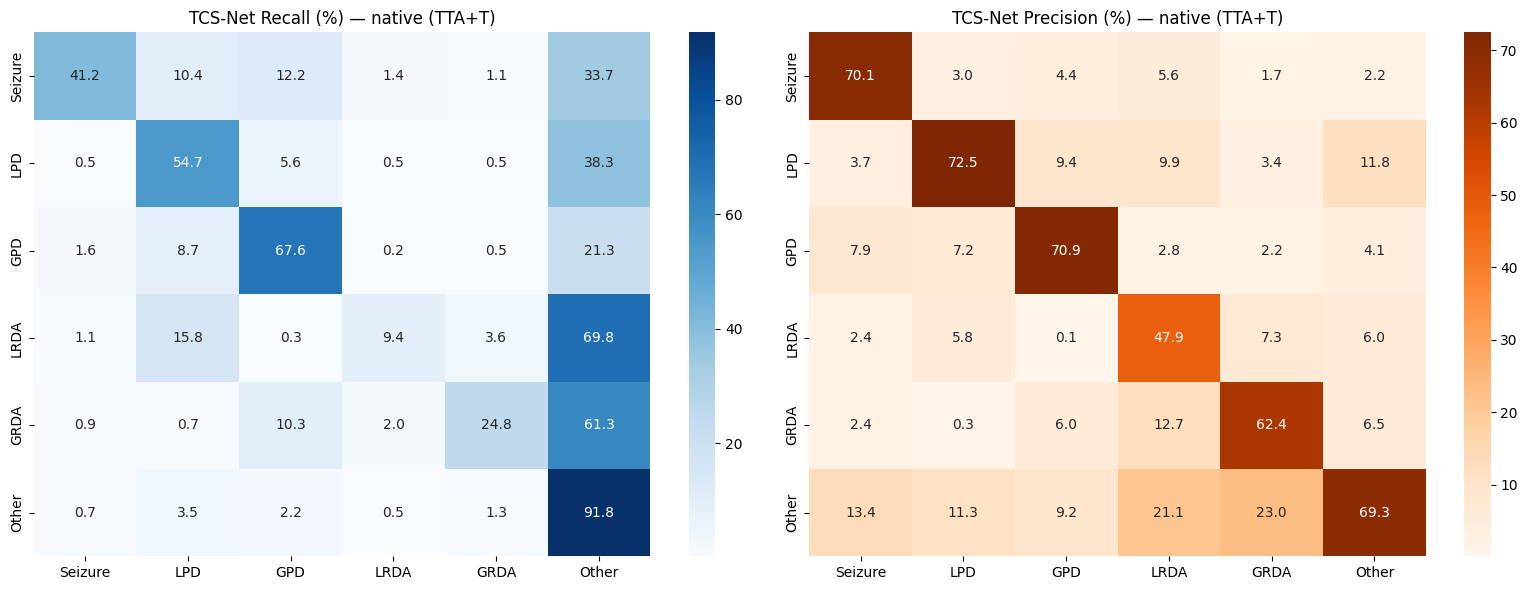


Saved /workspace/fair_comparison/tcsnet/confusion.png


In [29]:
# Per-class diagnostics on native-recipe predictions (TTA + T). The comparison notebook
# will produce the cross-model figures using the raw yp_raw_logits for apples-to-apples.

yti = all_yt.argmax(1); ypi = all_yp.argmax(1)
ytb = (yti[:, None] == np.arange(6)).astype(int)

print(f'{"Class":>8} | {"AUROC":>6} | {"AUROC(raw)":>10}')
print('-' * 40)
ypi_raw = all_yp_raw.argmax(1)
for i, nm in enumerate(CLASS_NAMES):
    try:
        auc     = roc_auc_score(ytb[:, i], all_yp[:, i])
        auc_raw = roc_auc_score(ytb[:, i], all_yp_raw[:, i])
        print(f'{nm:>8} | {auc:.3f} | {auc_raw:.3f}')
    except Exception as e:
        print(f'{nm:>8} | n/a ({e})')

cm   = confusion_matrix(yti, ypi, labels=range(6))
cm_r = cm.astype('float') / cm.sum(1, keepdims=True) * 100
cm_p = cm.astype('float') / cm.sum(0, keepdims=True) * 100

fig, (a1, a2) = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(cm_r, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=a1)
a1.set_title('TCS-Net Recall (%) — native (TTA+T)')
sns.heatmap(cm_p, annot=True, fmt='.1f', cmap='Oranges',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=a2)
a2.set_title('TCS-Net Precision (%) — native (TTA+T)')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/confusion.png', dpi=120)
plt.show()
print(f'\nSaved {OUT_DIR}/confusion.png')


## Done

Outputs saved to `/workspace/fair_comparison/tcsnet/`:
- `summary.json` — per-fold KLD (native + raw), temperatures, total wall-time, config
- `fold{0..4}_oof.npz` — yt, yp (native), yp_raw_logits (fair-comparison), wt, eeg_ids, spectrogram_ids, temperature
- `weights/fold{0..4}_best.pt` — model + EMA state
- `confusion.png` — confusion matrix on native predictions

**Expected results:**
- NATIVE KLD (TTA + T, what TCS-Net reports): ~0.33 (5-fold equivalent of the 0.329 10-fold number).
- RAW KLD (no TTA, no T, used in fair head-to-head): will be ~0.01–0.02 higher. This is the
  number the comparison notebook uses to pair against VIPEEGNet and EfficientNetB0.


